# Strategic sampling: a companion notebook

Fred J. Hickernell · Illinois Tech School of Computing colloquium · November 9, 2026

This notebook follows the [talk](../slides/StrategicSampling.qmd): an accessible Monte Carlo average, low discrepancy point designs, all-prefix behavior, and a stochastic beam. It adapts ideas from [MATH 565](https://github.com/fjhickernell/MATH565Fall2026) and [MCQMC 2026](https://github.com/fjhickernell/MCQMC26). The beam model and bounded Pydantic AI tool loop are adapted from Fred Hickernell's Simon Grant research prototype; the figures and numerical summaries below are recomputed here. Fixed seeds make these illustrations repeatable, not universal performance claims.

Run in the `qmcpy` kernel from this repository, with NumPy, SciPy, Matplotlib, and QMCPy installed. The final Pydantic AI cell is optional and needs `pydantic-ai-slim`. No API key or language model is needed for its scripted policy.

In [1]:
from pathlib import Path
import sys
import numpy as np
import matplotlib.pyplot as plt
import qmcpy as qp

ROOT = Path.cwd().resolve()
if not (ROOT / 'examples').exists():
    ROOT = ROOT.parent
if not (ROOT / 'examples' / 'beam').exists():
    raise RuntimeError('Run this notebook from its directory or the repository root')
sys.path.insert(0, str(ROOT))
FIG = ROOT / 'assets' / 'figures'
FIG.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
print('QMCPy', qp.__version__ if hasattr(qp, '__version__') else 'installed')

QMCPy 2.4


## A familiar question: how long should a trip take?

Adapted from the MATH 565 [“Are We There Yet?”](https://github.com/fjhickernell/MATH565Fall2026/blob/main/notebooks/applications/AreWeThereYet.ipynb) example: a 5-minute walk, a train wait between 0 and 20 minutes, a 30-minute train ride, a taxi ready with probability 0.2 (otherwise an exponential wait with mean 10 minutes), and a 12-minute taxi ride. The expected total is $5+10+30+8+12=65$ minutes, but an average does not tell us how much time to allow for a high chance of being on time. The histogram below uses 20,000 IID simulated trips as an illustration; it is not a prediction for an actual transit system.

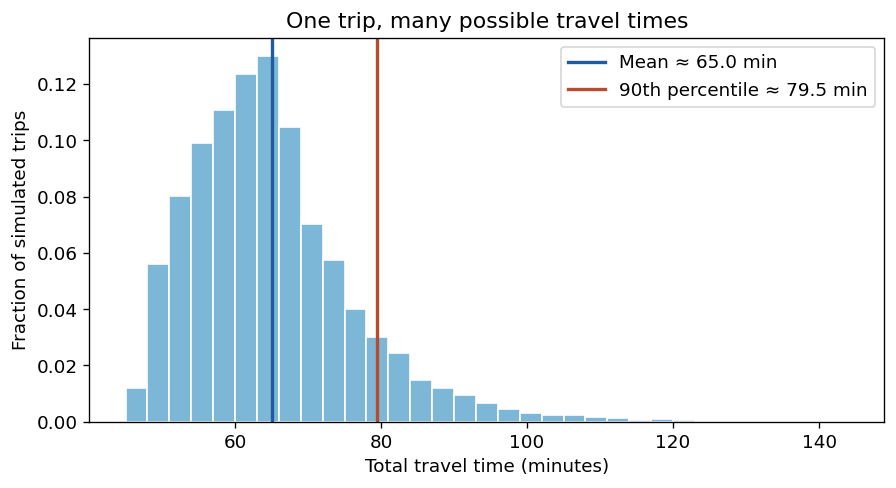

Simulated mean 65.01 min; simulated 90th percentile 79.47 min


In [2]:
rng = np.random.default_rng(20261109)
n_trips = 20_000
train_wait = 20 * rng.random(n_trips)
taxi_is_ready = rng.random(n_trips) < 0.2
taxi_wait = np.where(taxi_is_ready, 0, rng.exponential(10, n_trips))
trip_minutes = 5 + train_wait + 30 + taxi_wait + 12
mean_trip = trip_minutes.mean()
p90_trip = np.quantile(trip_minutes, 0.90)
fig, ax = plt.subplots(figsize=(7.6, 4.2))
ax.hist(trip_minutes, bins=np.arange(45, 146, 3), weights=np.ones(n_trips)/n_trips, color='#7db7d7', edgecolor='white')
ax.axvline(mean_trip, color='#1f5b9f', lw=2, label=f'Mean ≈ {mean_trip:.1f} min')
ax.axvline(p90_trip, color='#b84b2e', lw=2, label=f'90th percentile ≈ {p90_trip:.1f} min')
ax.set(xlabel='Total travel time (minutes)', ylabel='Fraction of simulated trips',
       title='One trip, many possible travel times')
ax.legend()
fig.tight_layout()
fig.savefig(FIG / 'trip_times.png', bbox_inches='tight')
plt.show()
print(f'Simulated mean {mean_trip:.2f} min; simulated 90th percentile {p90_trip:.2f} min')

## 1. From a question to an average

Suppose a simulation takes inputs $U=(U_1,U_2)$, each uniform on $[0,1]$, and returns $f(U)=\exp(U_1+U_2)$. Its exact average is $(e-1)^2$. This smooth example lets us check an estimator against the truth. In applications, one call to $f$ may solve a large physical or statistical model, and the exact average is unknown.

$$\mu=\int_{[0,1]^2}f(u)\,du,\qquad \widehat\mu_n=\frac1n\sum_{i=0}^{n-1}f(u_i).$$

In [3]:
def toy(u):
    return np.exp(np.asarray(u)[..., 0] + np.asarray(u)[..., 1])

truth = np.expm1(1.0) ** 2
for name, design in [('IID', qp.IIDStdUniform(2, seed=11)),
                     ("scrambled Sobol'", qp.Sobol(2, seed=11)),
                     ('shifted lattice', qp.Lattice(2, seed=11)),
                     ('shifted Kronecker', qp.Kronecker(2, seed=11))]:
    estimate = toy(design.gen_samples(64)).mean()
    print(f'{name:18s} estimate={estimate:.6f}  error={estimate-truth:+.6f}')
print(f'Exact average: {truth:.6f}')

IID                estimate=2.753089  error=-0.199403
scrambled Sobol'   estimate=2.952703  error=+0.000211
shifted lattice    estimate=2.962389  error=+0.009896
shifted Kronecker  estimate=2.931223  error=-0.021269
Exact average: 2.952492


## 2. Same budget, different coverage

IID samples may cluster and leave gaps. Low discrepancy (LD) designs organize the points. The plots show one randomized realization of each design; visual regularity alone does not establish a smaller integration error for every function.

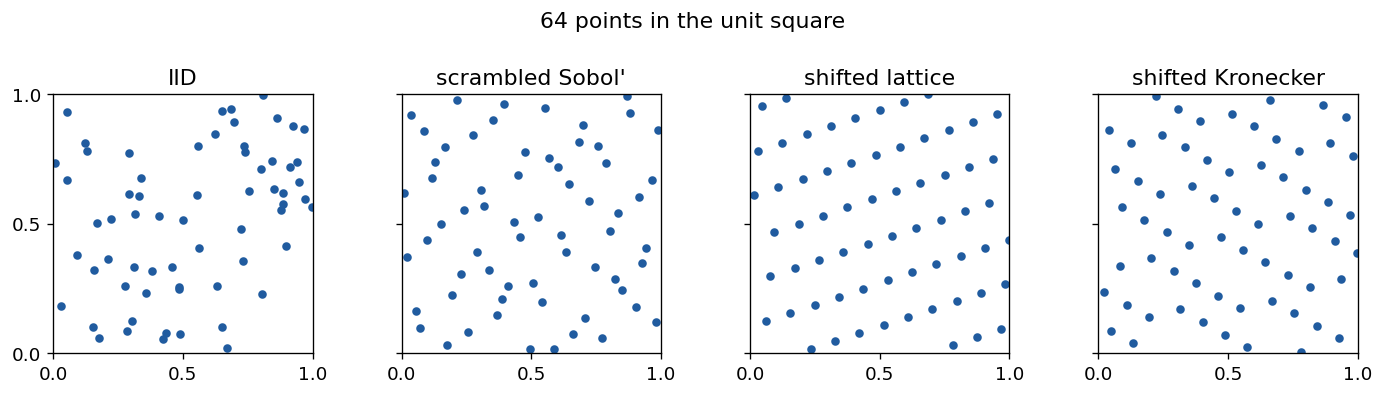

In [4]:
designs = [
    ('IID', qp.IIDStdUniform),
    ("scrambled Sobol'", qp.Sobol),
    ('shifted lattice', qp.Lattice),
    ('shifted Kronecker', qp.Kronecker),
]
fig, axes = plt.subplots(1, 4, figsize=(12, 3.0), sharex=True, sharey=True)
for ax, (label, family) in zip(axes, designs):
    u = family(2, seed=2026).gen_samples(64)
    ax.scatter(u[:, 0], u[:, 1], s=17, color='#205b9f')
    ax.set(xlim=(0, 1), ylim=(0, 1), title=label, aspect='equal')
    ax.set_xticks([0, .5, 1]); ax.set_yticks([0, .5, 1])
fig.suptitle('64 points in the unit square', y=1.04)
fig.tight_layout()
fig.savefig(FIG / 'coverage_four_methods.png', bbox_inches='tight')
plt.show()

## 3. Accuracy is about the integrand and the sample size

A randomized LD replicate keeps the geometry of its design while making each point uniform. Independent replications let us estimate the spread of estimates. The plot uses 24 independent replications per method and sample size; it shows empirical root mean squared error (RMSE) for this one smooth integral. It is an illustration, not a rate theorem.

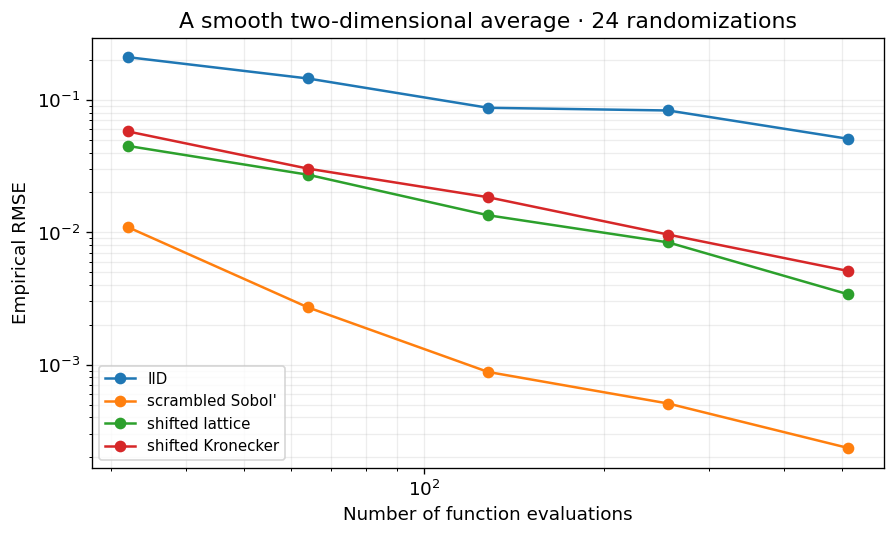

IID                n=512 RMSE 0.050742
scrambled Sobol'   n=512 RMSE 0.00023459
shifted lattice    n=512 RMSE 0.0033942
shifted Kronecker  n=512 RMSE 0.0050943


In [5]:
sizes = [32, 64, 128, 256, 512]
reps = 24
rmse = {}
for label, family in designs:
    values = []
    for n in sizes:
        estimates = [toy(family(2, seed=10000 + 1000*j + n).gen_samples(n)).mean()
                     for j in range(reps)]
        values.append(np.sqrt(np.mean((np.asarray(estimates) - truth)**2)))
    rmse[label] = np.array(values)

fig, ax = plt.subplots(figsize=(7.6, 4.6))
for label, _ in designs:
    ax.loglog(sizes, rmse[label], marker='o', label=label)
ax.set(xlabel='Number of function evaluations', ylabel='Empirical RMSE',
       title='A smooth two-dimensional average · 24 randomizations')
ax.grid(True, which='both', alpha=.22)
ax.legend(fontsize=9)
fig.tight_layout()
fig.savefig(FIG / 'toy_rmse.png', bbox_inches='tight')
plt.show()
for label, values in rmse.items():
    print(f'{label:18s} n=512 RMSE {values[-1]:.5g}')

## 4. The flexibility issue

QMCPy's default Sobol' and lattice generators emphasize powers of two for their standard balance properties. In particular, the default radical-inverse lattice interface below requires power-of-two sample counts. A Kronecker sequence naturally has a prefix at every positive integer. This is a software demonstration of the central research question, not a claim that any one family always wins.

In [6]:
from qmcpy.util import ParameterError

for n in (64, 97, 128):
    row = []
    for label, family in designs:
        try:
            points = family(2, seed=9).gen_samples(n)
            row.append(f'{label}: {len(points)}')
        except (ParameterError, ValueError, AssertionError) as exc:
            row.append(f'{label}: preferred sizes only ({type(exc).__name__})')
    print(f'n={n}: ' + ' | '.join(row))

# A newly requested Kronecker sample extends the prefix already used.
k64 = qp.Kronecker(2, seed=9).gen_samples(64)
k97 = qp.Kronecker(2, seed=9).gen_samples(97)
assert np.allclose(k64, k97[:64])
print('The first 64 Kronecker points are preserved when extended to 97.')

n=64: IID: 64 | scrambled Sobol': 64 | shifted lattice: 64 | shifted Kronecker: 64
n=97: IID: 97 | scrambled Sobol': preferred sizes only (ParameterError) | shifted lattice: preferred sizes only (AssertionError) | shifted Kronecker: 97
n=128: IID: 128 | scrambled Sobol': 128 | shifted lattice: 128 | shifted Kronecker: 128
The first 64 Kronecker points are preserved when extended to 97.


## 5. A stochastic beam: making each evaluation more realistic

The dimensionless beam is clamped at both ends and has uncertain stiffness $B(x,Z)$ with eight Gaussian inputs. For each input $Z$, we compute the normalized midpoint deflection $Y(Z)=384w(1/2,Z)$; uniform stiffness gives $Y=1$. We seek $E[Y]$. The included solver uses equilibrium and compatibility with numerical quadrature. Its spatial-cell count controls quadrature resolution. This synthetic model is not calibrated to a particular material.

The full [beam model](../examples/beam/model.py) is adapted from the Simon Grant prototype. Here we compare IID MC and randomized Sobol' at the **same number of beam solves**. Each dot is the standard deviation of 12 independent replicate estimates; it is a sampling-variability diagnostic, not a certified error bound.

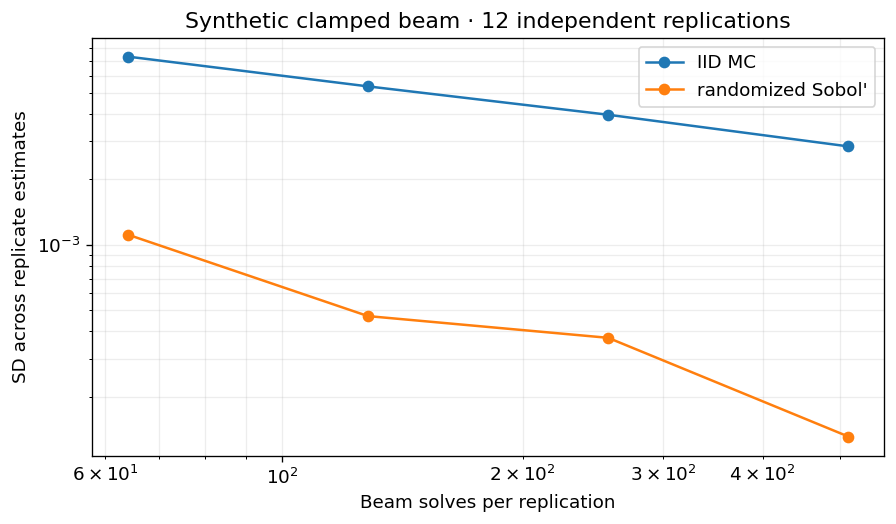

IID MC             n=512 mean 1.116465, replicate SD 0.002835
randomized Sobol'  n=512 mean 1.116169, replicate SD 0.00013149


In [7]:
from examples.beam.model import response, DIMENSION
from scipy.special import ndtri

beam_sizes = [64, 128, 256, 512]
beam_reps = 12
beam_spread = {}
beam_mean = {}
for label, family in [('IID MC', qp.IIDStdUniform), ("randomized Sobol'", qp.Sobol)]:
    sd_list, mean_list = [], []
    for n in beam_sizes:
        u = family(DIMENSION, replications=beam_reps, seed=20000+n).gen_samples(n)
        z = ndtri(np.clip(u, np.finfo(float).eps, 1-np.finfo(float).eps))
        estimates = response(z, cells=8).mean(axis=1)
        sd_list.append(estimates.std(ddof=1))
        mean_list.append(estimates.mean())
    beam_spread[label] = np.array(sd_list)
    beam_mean[label] = np.array(mean_list)

fig, ax = plt.subplots(figsize=(7.6, 4.5))
for label, values in beam_spread.items():
    ax.loglog(beam_sizes, values, marker='o', label=label)
ax.set(xlabel='Beam solves per replication', ylabel='SD across replicate estimates',
       title='Synthetic clamped beam · 12 independent replications')
ax.grid(True, which='both', alpha=.22)
ax.legend()
fig.tight_layout()
fig.savefig(FIG / 'beam_sampling_variability.png', bbox_inches='tight')
plt.show()
for label in beam_spread:
    print(f'{label:18s} n=512 mean {beam_mean[label][-1]:.6f}, '
          f'replicate SD {beam_spread[label][-1]:.5g}')

## 6. AI can coordinate a bounded experiment

The included [Pydantic AI tool-loop example](../examples/beam/agent.py) exposes four tools: describe the experiment, check paired spatial refinements, run an MC or randomized QMC pilot, and validate **once** using fresh randomizations. The saved demonstration in the source prototype used Pydantic AI with a **scripted policy**, not a live language model. The same offline policy is included here, but requires the optional `pydantic-ai-slim` package. It records actual numerical results and its decision path. A live model can use the same tools when separately configured, but no live-model conclusion is claimed in this notebook.

The pilot's sample-size extrapolation is a planning heuristic; a 99% Student-$t$ half-width from independent replicate means is approximate. The finite-panel spatial refinement check is a diagnostic rather than a bound on all unseen inputs.

In [8]:
import importlib.util
if importlib.util.find_spec('pydantic_ai') is None:
    print('Optional Pydantic AI package is not installed in this kernel.')
    print('Install pydantic-ai-slim in a suitable environment, then rerun this cell.')
else:
    from tempfile import TemporaryDirectory
    from examples.beam.agent import run
    with TemporaryDirectory() as output_dir:
        result = run(output_dir)  # scripted policy; no LLM or API key
        print(result['agent_summary'])
        print('Beam solves including refinements and pilots:', result['total_beam_solves'])

Optional Pydantic AI package is not installed in this kernel.
Install pydantic-ai-slim in a suitable environment, then rerun this cell.


## What to remember

- An MC calculation estimates an average using repeated model evaluations
- LD changes **where** the model is evaluated; randomized replications let us assess sampling variability
- A practically useful sequence should retain earlier work and behave well across sample counts
- The beam example shows how the sampler, physical solver, numerical diagnostics, and a bounded decision process fit together

**Sources:** [MATH 565 sampling and efficiency slides](https://github.com/fjhickernell/MATH565Fall2026/tree/main/slides), [MCQMC 2026 plenary and special-session decks](https://github.com/fjhickernell/MCQMC26/tree/main/slides), [QMCPy](https://qmcpy.org/).